Skrypt demonstruje AutoEval na przykładzie ewaluacji jakości odpowiedzi generowanych przez system agentowy dla zadań matematycznych. Wykorzystuje bibliotekę autogen do generowania kryteriów oceny, analizuje poprawność rozwiązań w różnych przypadkach testowych, a następnie wizualizuje wyniki w formie wykresu słupkowego z przedziałami ufności.

# Setup

In [14]:
!pip install -q "ag2>=0.2.3" docker scipy matplotlib

asd

In [ ]:
import json
import os
from contextlib import suppress
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

from autogen.agentchat.contrib.agent_eval.agent_eval import (
    generate_criteria,
    quantify_criteria,
)
from autogen.agentchat.contrib.agent_eval.criterion import Criterion
from autogen.agentchat.contrib.agent_eval.task import Task

from google.colab import userdata

Ten kod importuje szereg bibliotek i modułów potrzebnych do uruchomienia systemu opartego na agentach, z naciskiem na ewaluację ich działania. Rozbijmy to po kolei:

*   **`contextlib.suppress`**: Pozwala na eleganckie ignorowanie określonych wyjątków, co ułatwia obsługę błędów w kodzie.
*   **`matplotlib.pyplot as plt`**: Biblioteka do tworzenia wykresów i wizualizacji danych.
*   **`numpy as np`**: Podstawowa biblioteka do obliczeń numerycznych w Pythonie, oferująca efektywne struktury danych (np. tablice) i funkcje matematyczne.
*   **`scipy.stats as stats`**: Zawiera narzędzia do analizy statystycznej, takie jak testy hipotez czy generowanie rozkładów prawdopodobieństwa.
*   **`autogen.agentchat.contrib.agent_eval.*`**: Moduły z biblioteki `autogen` odpowiedzialne za ewaluację działania agentów. Konkretnie:
    *   `generate_criteria`: Generuje kryteria oceny dla agentów.
    *   `quantify_criteria`: Kwantyfikuje (przypisuje wartości liczbowe) wyniki oceny na podstawie zdefiniowanych kryteriów.
    *   `Criterion`: Klasa reprezentująca pojedyncze kryterium ewaluacji.
    *   `Task`: Klasa reprezentująca zadanie, które agenci mają wykonać i które jest oceniane.

In [ ]:
config_list = [{"model": "gpt-4.1", "api_key": userdata.get("openaivision")}]


model_config = {
    "cache_seed": 42,
    "temperature": 0,
    "config_list": config_list,
    "timeout": 120,
}

# Functions

In [ ]:
def remove_ground_truth(test_case):
    test_details = json.loads(test_case)
    # need to remove the ground truth from the test details
    correctness = test_details.pop("is_correct", None)
    test_details.pop("correct_ans", None)
    test_details.pop("check_result", None)
    return str(test_details), correctness

Ta funkcja, nazwana `remove_ground_truth`, przyjmuje jako argument ciąg znaków `test_case` reprezentujący testowy przypadek w formacie JSON i modyfikuje go poprzez usunięcie informacji o "prawidłowej odpowiedzi" (ground truth).

1.  **`test_details = json.loads(test_case)`**: Parsuje łańcuch `test_case` z formatu JSON do słownika Pythona, który jest przechowywany w zmiennej `test_details`. Dzięki temu można łatwo manipulować danymi zawartymi w teście.

2.  **`correctness = test_details.pop("is_correct", None)`**: Usuwa klucz `"is_correct"` ze słownika `test_details` i przypisuje jego wartość do zmiennej `correctness`. Metoda `.pop()` usuwa element ze słownika i zwraca jego wartość. Argument `None` oznacza, że jeśli klucz `"is_correct"` nie istnieje w słowniku, funkcja zwróci `None` zamiast zgłosić błąd. Zmienna `correctness` przechowuje informację o tym, czy odpowiedź agenta była poprawna zgodnie z "prawidłową odpowiedzią".

3.  **`test_details.pop("correct_ans", None)`**: Usuwa klucz `"correct_ans"` ( zawierający prawidłową odpowiedź) ze słownika `test_details`. Podobnie jak w poprzednim kroku, używany jest argument `None`, aby uniknąć błędu, jeśli klucz nie istnieje.

4.  **`test_details.pop("check_result", None)`**: Usuwa klucz `"check_result"` ( zawierający wynik sprawdzenia odpowiedzi) ze słownika `test_details`. Argument `None` zapobiega błędom, jeśli klucz nie istnieje.

5.  **`return str(test_details), correctness`**: Konwertuje zmodyfikowany słownik `test_details` z powrotem na łańcuch JSON za pomocą funkcji `str()` i zwraca go razem ze zmienną `correctness`. Zwracana krotka zawiera więc testowy przypadek bez informacji o prawidłowej odpowiedzi oraz informację, czy oryginalna odpowiedź była poprawna.

Funkcja ta jest przydatna w scenariuszach, gdzie chcemy ocenić agentów na podstawie ich własnych odpowiedzi, a nie porównywać je z wcześniej znanymi "prawidłowymi" rozwiązaniami. Pozwala to na bardziej obiektywną ocenę kreatywności i umiejętności rozwiązywania problemów przez agenta.

# Krytyk raz

In [19]:
!cat /content/sample_math_response_successful.txt

{
  "problem": "What is the sum of all the distinct positive two-digit factors of 144?",
  "level": "Level 5",
  "type": "Number Theory",
  "solution": "Prime factorize $144=2^4\\cdot3^2$. The sum of the positive two-digit factors of 144 is $2^4+2\\cdot3^2+2^2\\cdot3+2^2\\cdot3^2+2^3\\cdot3+2^3\\cdot3^2+2^4\\cdot3=\\boxed{226}.$",
  "correct_ans": "226",
  "problem_id": "0",
  "response_with_ans": "To find the sum of all the distinct positive two-digit factors of 144, we need to first find all these factors. We can do this by iterating through the numbers from 10 to 99 and checking if they are factors of 144. Then, we can sum these factors and print their sum.\n\nHere's a Python script to accomplish this:\n\n```python\ntwo_digit_factors = []\n\nfor i in range(10, 100):\n    if 144 % i == 0:\n        two_digit_factors.append(i)\n\nsum_of_factors = sum(two_digit_factors)\nprint(\"The sum of all the distinct positive two-digit factors of 144 is:\", sum_of_factors)\n```\n\nPlease run this 

In [20]:
!cat /content/sample_math_response_failed.txt

{
  "problem": "Find all $x$ that satisfy the inequality $(2x+10)(x+3)<(3x+9)(x+8)$. Express your answer in interval notation.",
  "level": "Level 5",
  "type": "Algebra",
  "solution": "We have \\begin{align*} (2x+10)(x+3)&<(3x+9)(x+8) \\quad \\Rightarrow\n\\\\ 2(x+5)(x+3)&<3(x+3)(x+8) \\quad \\Rightarrow\n\\\\ 2(x+5)(x+3)-3(x+3)(x+8)&<0 \\quad \\Rightarrow\n\\\\ (2x+10-(3x+24))(x+3)&<0 \\quad \\Rightarrow\n\\\\ (-x-14)(x+3)&<0 \\quad \\Rightarrow\n\\\\ (x+14)(x+3)&>0.\n\\end{align*} This inequality is satisfied if and only if $(x+14)$ and $(x+3)$ are either both positive or both negative.  Both factors are positive for $x>-3$ and both factors are negative for $x<-14$.  When $-14<x<-3$, one factor is positive and the other negative, so their product is negative.   Therefore, the range of $x$ that satisfies the inequality is $ \\boxed{(-\\infty, -14)\\cup(-3,\\infty)} $.",
  "correct_ans": "(-\\infty, -14)\\cup(-3,\\infty)",
  "problem_id": "0",
  "response_with_ans": "I apologize for 

In [ ]:
# przygotowanie danych
success_str = open("/content/sample_math_response_successful.txt").read()
response_successful = remove_ground_truth(success_str)[0]
failed_str = open("/content/sample_math_response_failed.txt").read()
response_failed = remove_ground_truth(failed_str)[0]

task = Task(
    **{
        "name": "Math problem solving",
        "description": "Given any question, the system needs to solve the problem as concisely and accurately as possible",
        "successful_response": response_successful,
        "failed_response": response_failed,
    }
)

criteria = generate_criteria(
    task=task, llm_config={"config_list": config_list}, max_round=8
)


critic_user (to chat_manager):

Task: Math problem solving.
        Task description: Given any question, the system needs to solve the problem as consisely and accurately as possible
        Task successful example: {'problem': 'What is the sum of all the distinct positive two-digit factors of 144?', 'level': 'Level 5', 'type': 'Number Theory', 'solution': 'Prime factorize $144=2^4\\cdot3^2$. The sum of the positive two-digit factors of 144 is $2^4+2\\cdot3^2+2^2\\cdot3+2^2\\cdot3^2+2^3\\cdot3+2^3\\cdot3^2+2^4\\cdot3=\\boxed{226}.$', 'problem_id': '0', 'response_with_ans': 'To find the sum of all the distinct positive two-digit factors of 144, we need to first find all these factors. We can do this by iterating through the numbers from 10 to 99 and checking if they are factors of 144. Then, we can sum these factors and print their sum.\n\nHere\'s a Python script to accomplish this:\n\n```python\ntwo_digit_factors = []\n\nfor i in range(10, 100):\n    if 144 % i == 0:\n        two_digi

Kod ten przygotowuje dane i konfigurację do oceny działania systemu rozwiązującego zadania matematyczne.

Najpierw wczytuje zawartość dwóch plików tekstowych: `/content/sample_math_response_successful.txt` oraz `/content/sample_math_response_failed.txt`.  Zawartość tych plików reprezentuje odpowiednio udaną i nieudaną próbę rozwiązania zadania matematycznego przez system. Funkcja `remove_ground_truth()` jest używana do przetworzenia tych tekstów, usuwając z nich poprawne odpowiedzi (tzw. "ground truth") – istotne jest żeby oceniać jedynie generowaną odpowiedź systemu, a nie porównywać ją bezpośrednio z wzorcem. Wynik tej funkcji, czyli oczyszczony tekst reprezentujący udaną i nieudaną odpowiedź, jest przypisywany do zmiennych `response_successful` oraz `response_failed`.

Następnie tworzony jest obiekt klasy `Task`. Ten obiekt zawiera informacje o zadaniu, które ma być oceniane.  Parametry przekazywane do konstruktora (`**{...}`) definiują:
*   `name`: Nazwę zadania ("Math problem solving").
*   `description`: Opis zadania (system ma rozwiązywać problemy matematyczne w sposób zwięzły i dokładny).
*   `successful_response`: Przykładową, udaną odpowiedź systemu.
*   `failed_response`: Przykładową, nieudaną odpowiedź systemu.

Na końcu kod wywołuje funkcję `generate_criteria()`. Funkcja ta generuje kryteria oceny na podstawie zdefiniowanego zadania (`task`) i konfiguracji modelu językowego (`llm_config`).  Konfiguracja modelu jest przekazywana w postaci listy ustawień (`config_list`), a parametr `max_round` określa maksymalną liczbę rund oceny (ustawioną na 8). Wynik tej funkcji, czyli wygenerowane kryteria oceny, jest przypisywany do zmiennej `criteria`.


In [22]:
current_task_name = "_".join(task.name.split()).lower()
cr_file = open(f"/content/{current_task_name}_criteria.json", "w")
cr_file.write(Criterion.write_json(criteria))
cr_file.close()

Kod ten zapisuje wygenerowane kryteria oceny do pliku JSON.

Najpierw tworzona jest nazwa pliku na podstawie nazwy zadania (`task.name`). Funkcja `split()` dzieli nazwę zadania na listę słów, a następnie `"_".join(...)` łączy te słowa za pomocą podkreślenia. Na koniec `.lower()` konwertuje całą nazwę na małe litery. Wynik przypisywany jest do zmiennej `current_task_name`.

Następnie otwierany jest plik o nazwie odpowiadającej wygenerowanej nazwie zadania, z rozszerzeniem ".json", w katalogu `/content/`. Plik jest otwierany w trybie zapisu ("w").

Funkcja `Criterion.write_json(criteria)` konwertuje obiekt `criteria` (który zawiera kryteria oceny) na format JSON.  Wynikiem tej funkcji jest ciąg znaków reprezentujący dane w formacie JSON, który następnie zapisywany jest do otwartego pliku za pomocą metody `write()`.

Na końcu plik jest zamykany za pomocą metody `close()`, co zapewnia poprawne zapisanie danych na dysku.

In [23]:
criteria_file = f"/content/{current_task_name}_criteria.json"
criteria = open(criteria_file).read()
criteria = Criterion.parse_json_str(criteria)

Kod ten wczytuje kryteria oceny z pliku JSON, który został wcześniej zapisany.

Najpierw tworzona jest ścieżka do pliku zawierającego kryteria oceny (`criteria_file`). Ścieżka ta składa się z katalogu `/content/`, nazwy zadania (przechowywanej w zmiennej `current_task_name`) oraz rozszerzenia ".json".

Następnie otwierany jest plik o podanej ścieżce i jego zawartość jest odczytywana jako ciąg znaków za pomocą funkcji `open(...).read()`.  Ten ciąg znaków, reprezentujący dane w formacie JSON, jest przypisywany do zmiennej `criteria`.

Na końcu kod używa funkcji `Criterion.parse_json_str(criteria)` do przetworzenia ciągu znaków JSON i przekształcenia go z powrotem na obiekt `Criterion`.  Ten obiekt zawiera teraz kryteria oceny w postaci struktury danych, którą można wykorzystać do dalszej analizy lub oceny wyników systemu.

In [24]:
test_case = open("/content/sample_test_case.json").read()
test_case, ground_truth = remove_ground_truth(test_case)
quantifier_output = quantify_criteria(
    llm_config={"config_list": config_list},
    criteria=criteria,
    task=task,
    test_case=test_case,
    ground_truth=ground_truth,
)
print("actual correctness:", quantifier_output["actual_success"])
print("predicted correctness:\n", quantifier_output["estimated_performance"])

quantifier_user (to quantifier):

Task: Math problem solving.
        Task description: Given any question, the system needs to solve the problem as consisely and accurately as possible
        Task successful example: {'problem': 'What is the sum of all the distinct positive two-digit factors of 144?', 'level': 'Level 5', 'type': 'Number Theory', 'solution': 'Prime factorize $144=2^4\\cdot3^2$. The sum of the positive two-digit factors of 144 is $2^4+2\\cdot3^2+2^2\\cdot3+2^2\\cdot3^2+2^3\\cdot3+2^3\\cdot3^2+2^4\\cdot3=\\boxed{226}.$', 'problem_id': '0', 'response_with_ans': 'To find the sum of all the distinct positive two-digit factors of 144, we need to first find all these factors. We can do this by iterating through the numbers from 10 to 99 and checking if they are factors of 144. Then, we can sum these factors and print their sum.\n\nHere\'s a Python script to accomplish this:\n\n```python\ntwo_digit_factors = []\n\nfor i in range(10, 100):\n    if 144 % i == 0:\n        two_di

Kod ten przeprowadza ocenę konkretnego przypadku testowego przy użyciu wcześniej zdefiniowanych kryteriów i modelu językowego.

Najpierw wczytuje zawartość pliku `/content/sample_test_case.json` jako ciąg znaków, który reprezentuje przypadek testowy. Następnie funkcja `remove_ground_truth()` jest wywoływana na tym ciągu, aby oddzielić sam przypadek testowy od poprawnej odpowiedzi (tzw. "ground truth"). Wyniki są przypisywane do zmiennych `test_case` i `ground_truth`.

Następnie wywoływana jest funkcja `quantify_criteria()`, która przeprowadza właściwą ocenę. Funkcja ta przyjmuje następujące argumenty:
*   `llm_config`: Konfiguracja modelu językowego (lista ustawień).
*   `criteria`: Kryteria oceny, które zostały wcześniej wczytane z pliku JSON.
*   `task`: Obiekt `Task`, który definiuje zadanie do oceny.
*   `test_case`: Sam przypadek testowy.
*   `ground_truth`: Poprawna odpowiedź dla tego przypadku testowego.

Funkcja `quantify_criteria()` zwraca słownik zawierający wyniki oceny, które są następnie przypisywane do zmiennej `quantifier_output`. Słownik ten zawiera co najmniej dwa klucze:
*   `"actual_success"`: Wartość reprezentująca rzeczywistą poprawność rozwiązania (binarna wartość wskazująca, czy rozwiązanie jest poprawne).
*   `"estimated_performance"`: Wyniki szacowanego działania systemu,  w postaci metryk / analizy jakości odpowiedzi.

Na końcu kod wyświetla na ekranie wartość `"actual_success"` oraz zawartość słownika `"estimated_performance"`.  Wyświetlenie tych wartości pozwala na ocenę skuteczności systemu i zrozumienie jego mocnych i słabych stron.

# Krytyk po wielokroć

In [25]:
!mkdir agentchat_results
log_path = "/content/agentchat_results/"


!wget https://github.com/julianakiseleva/autogen/raw/ddabd4f0e7c13a50e33cf8462e79358666371477/test/test_files/agenteval-in-out/prealgebra.zip
!unzip -o prealgebra.zip -d {log_path}
!rm  prealgebra.zip

assert Path(log_path).exists(), f"The log path '{log_path}' does not exist."

mkdir: cannot create directory ‘agentchat_results’: File exists
--2025-05-19 09:28:47--  https://github.com/julianakiseleva/autogen/raw/ddabd4f0e7c13a50e33cf8462e79358666371477/test/test_files/agenteval-in-out/prealgebra.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/julianakiseleva/autogen/ddabd4f0e7c13a50e33cf8462e79358666371477/test/test_files/agenteval-in-out/prealgebra.zip [following]
--2025-05-19 09:28:48--  https://raw.githubusercontent.com/julianakiseleva/autogen/ddabd4f0e7c13a50e33cf8462e79358666371477/test/test_files/agenteval-in-out/prealgebra.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response...

Kod ten przygotowuje środowisko do przechowywania i pobierania danych testowych związanych z oceną agentów konwersacyjnych (agentchat).

Najpierw tworzony jest katalog o nazwie `agentchat_results` wewnątrz `/content/`.  Używana jest komenda `!mkdir agentchat_results`, która wywołuje polecenie systemowe do utworzenia katalogu. Zmienna `log_path` przechowuje ścieżkę do tego nowo utworzonego katalogu, czyli `/content/agentchat_results/`.

Następnie pobierany jest plik ZIP o nazwie `prealgebra.zip` z repozytorium GitHub pod adresem `https://github.com/julianakiseleva/autogen/raw/ddabd4f0e7c13a50e33cf8462e79358666371477/test/test_files/agenteval-in-out/prealgebra.zip`. Używana jest komenda `!wget`, która wywołuje polecenie systemowe do pobrania pliku z podanego adresu URL.

Pobrany plik ZIP jest następnie rozpakowywany do katalogu `/content/agentchat_results/` za pomocą komendy `!unzip -o prealgebra.zip -d {log_path}`. Opcja `-o` powoduje nadpisanie istniejących plików w katalogu docelowym, jeśli takie istnieją.

Plik ZIP `prealgebra.zip` jest następnie usuwany z `/content/` za pomocą komendy `!rm prealgebra.zip`.

Na końcu kod sprawdza, czy katalog o ścieżce przechowywanej w zmiennej `log_path` rzeczywiście istnieje.  Używana jest funkcja `Path(log_path).exists()`, która zwraca wartość logiczną `True`, jeśli katalog istnieje, i `False` w przeciwnym razie. Jeśli katalog nie istnieje, program zgłasza błąd (`AssertionError`) z odpowiednim komunikatem.

In [26]:
!cat ./agentchat_results/prealgebra/0.json

{
  "problem": "Triangle $ABC$ is a right triangle. If the measure of angle $PAB$ is $x^\\circ$ and the measure of angle $ACB$ is expressed in the form $(Mx+N)^\\circ$ with $M=1$, what is the value of $M+N$?\n\n[asy]\ndraw((-10,0)--(20,0),linewidth(1),Arrows);\ndraw((0,0)--(10,10/sqrt(3))--(10+10/3,0),linewidth(1));\n\ndraw((10,10/sqrt(3))+dir(-150)--(10,10/sqrt(3))+dir(-150)+dir(-60)--(10,10/sqrt(3))+dir(-60),linewidth(1));\n\ndot((-3,0));\n\ndraw(dir(180)..dir(105)..dir(30),linewidth(1));\n\nlabel(\"P\",(-3,0),NW);\nlabel(\"A\",(0,0),S);\nlabel(\"$x^\\circ$\",(-1,1),N);\nlabel(\"B\",(10,10/sqrt(3)),N);\nlabel(\"C\",(10+10/3,0),NE);\n\n[/asy]",
  "level": "Level 5",
  "type": "Prealgebra",
  "solution": "Since $\\angle PAB$ and $\\angle BAC$ are supplementary, $\\angle BAC = 180^{\\circ} - x^\\circ$.  Since the three angles of a triangle add up to $ 180^{\\circ} $, we have $\\angle ACB = 180^{\\circ} - 90^{\\circ} - (180^{\\circ} - x^\\circ) = x^\\circ - 90^{\\circ}$.  Thus, $M + N = 

In [27]:
criteria_file = "/content/sample_math_criteria.json"
criteria = Criterion.parse_json_str(open(criteria_file).read())
outcome = {}

Kod ten wczytuje kryteria oceny z pliku i inicjalizuje słownik do przechowywania wyników.

Najpierw definiowana jest zmienna `criteria_file`, która przechowuje ścieżkę do pliku JSON zawierającego kryteria oceny, czyli `/content/sample_math_criteria.json`.

Następnie wczytywana jest zawartość tego pliku za pomocą funkcji `open(criteria_file).read()`.  Funkcja `open()` otwiera plik do odczytu, a metoda `.read()` odczytuje całą jego zawartość jako ciąg znaków. Ten ciąg znaków JSON jest następnie przekazywany do funkcji `Criterion.parse_json_str()`, która przetwarza go i konwertuje z powrotem na obiekt `Criterion`.  Wynik tego procesu, czyli obiekt reprezentujący kryteria oceny, jest przypisywany do zmiennej `criteria`.

Na końcu inicjalizowany jest pusty słownik o nazwie `outcome`. Słownik ten będzie używany do przechowywania wyników oceny dla różnych przypadków testowych lub interakcji z agentem.

In [ ]:
for prefix in os.listdir(log_path):
    for file_name in os.listdir(log_path + "/" + prefix):
        gameid = prefix + "_" + file_name
        if file_name.split(".")[-1] == "json":
            test_case, ground_truth = remove_ground_truth(
                open(log_path + "/" + prefix + "/" + file_name).read()
            )
            quantifier_output = quantify_criteria(
                llm_config={"config_list": config_list},
                criteria=criteria,
                task=task,
                test_case=test_case,
                ground_truth=ground_truth,
            )
            outcome[gameid] = quantifier_output

# store the evaluated problems
with open("/content/evaluated_problems.json", "w") as file:
    json.dump(outcome, file, indent=2)

quantifier_user (to quantifier):

Task: Math problem solving.
        Task description: Given any question, the system needs to solve the problem as consisely and accurately as possible
        Task successful example: {'problem': 'What is the sum of all the distinct positive two-digit factors of 144?', 'level': 'Level 5', 'type': 'Number Theory', 'solution': 'Prime factorize $144=2^4\\cdot3^2$. The sum of the positive two-digit factors of 144 is $2^4+2\\cdot3^2+2^2\\cdot3+2^2\\cdot3^2+2^3\\cdot3+2^3\\cdot3^2+2^4\\cdot3=\\boxed{226}.$', 'problem_id': '0', 'response_with_ans': 'To find the sum of all the distinct positive two-digit factors of 144, we need to first find all these factors. We can do this by iterating through the numbers from 10 to 99 and checking if they are factors of 144. Then, we can sum these factors and print their sum.\n\nHere\'s a Python script to accomplish this:\n\n```python\ntwo_digit_factors = []\n\nfor i in range(10, 100):\n    if 144 % i == 0:\n        two_di

Kod ten iteruje po plikach JSON w katalogach i podkatalogach, ocenia je przy użyciu wcześniej zdefiniowanych kryteriów i zapisuje wyniki do pliku JSON.

Najpierw kod przechodzi przez wszystkie katalogi znajdujące się bezpośrednio wewnątrz katalogu `log_path` (czyli `/content/agentchat_results/`). Używana jest funkcja `os.listdir(log_path)` do uzyskania listy nazw tych katalogów, a pętla `for prefix in ...:` iteruje po każdym z nich.

Wewnątrz zewnętrznej pętli kod przechodzi przez wszystkie pliki znajdujące się w bieżącym podkatalogu (określonym przez zmienną `prefix`). Używana jest funkcja `os.listdir(log_path + "/" + prefix)` do uzyskania listy nazw plików, a pętla `for file_name in ...:` iteruje po każdym z nich.

Dla każdego pliku tworzona jest unikalna identyfikacja (`gameid`) poprzez połączenie nazwy podkatalogu (`prefix`) i nazwy pliku (`file_name`), oddzielonych znakiem podkreślenia.

Następnie sprawdzane jest, czy rozszerzenie pliku to "json".  Używana jest metoda `file_name.split(".")[-1]` do pobrania ostatniej części nazwy pliku po kropce (czyli rozszerzenia). Jeśli rozszerzenie to "json", kod przechodzi do oceny tego pliku.

Wczytywana jest zawartość pliku JSON za pomocą funkcji `open(...)`. Następnie funkcja `remove_ground_truth()` jest wywoływana, aby oddzielić przypadek testowy od poprawnej odpowiedzi. Wyniki są przypisywane do zmiennych `test_case` i `ground_truth`.

Następnie wywoływana jest funkcja `quantify_criteria()`, która ocenia przypadek testowy przy użyciu wcześniej zdefiniowanych kryteriów (`criteria`), zadania (`task`), przypadku testowego (`test_case`) oraz poprawnej odpowiedzi (`ground_truth`). Wynik tej funkcji, czyli słownik zawierający wyniki oceny, jest przypisywany do zmiennej `quantifier_output`.

Wyniki oceny dla bieżącego pliku (reprezentowane przez `quantifier_output`) są zapisywane w słowniku `outcome` pod kluczem odpowiadającym identyfikatorowi (`gameid`) tego pliku.

Po zakończeniu iteracji po wszystkich plikach JSON, kod otwiera plik `/content/evaluated_problems.json` w trybie zapisu ("w"). Następnie używana jest funkcja `json.dump()` do zapisania zawartości słownika `outcome` do tego pliku w formacie JSON. Parametr `indent=2` powoduje dodanie wcięć do pliku JSON, co poprawia jego czytelność.

In [ ]:
# mean + std => CI

with suppress(Exception):
    criteria = Criterion.parse_json_str(open(criteria_file).read())


nl2int = {}
for criterion in criteria:
    for score, v in enumerate(criterion.accepted_values):
        nl2int[v] = score
print(nl2int)

average_s = {}
average_f = {}

conf_interval_s = {}
conf_interval_f = {}

for criterion in criteria:
    task = {"s": [], "f": []}

    for game in outcome:
        with suppress(Exception):
            tmp_dic = eval(outcome[game]["estimated_performance"])
            if outcome[game]["actual_success"] == "false":
                task["f"].append(nl2int[tmp_dic[criterion.name]])
            else:
                task["s"].append(nl2int[tmp_dic[criterion.name]])

    average_f[criterion.name] = np.mean(task["f"])
    average_s[criterion.name] = np.mean(task["s"])

    conf_interval_s[criterion.name] = stats.norm.interval(
        0.95, loc=np.mean(task["s"]), scale=stats.sem(task["s"])
    )
    conf_interval_f[criterion.name] = stats.norm.interval(
        0.95, loc=np.mean(task["f"]), scale=stats.sem(task["f"])
    )

{'completely off': 0, 'slightly relevant': 1, 'relevant': 2, 'mostly accurate': 3, 'completely accurate': 4, 'inappropriate': 0, 'barely adequate': 1, 'adequate': 2, 'mostly effective': 3, 'completely effective': 4, 'completely incorrect': 0, 'mostly incorrect': 1, 'neither': 2, 'mostly correct': 3, 'completely correct': 4, 'not at all clear': 0, 'slightly clear': 1, 'moderately clear': 2, 'very clear': 3, 'completely clear': 4, 'not at all efficient': 0, 'slightly efficient': 1, 'moderately efficient': 2, 'very efficient': 3, 'extremely efficient': 4, 'partly correct': 2}


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
<ipython-input-29-e7276515ea70>:34: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  conf_interval_f[criterion.name] = stats.norm.interval(0.95, loc=np.mean(task["f"]), scale=stats.sem(task["f"]))


asd

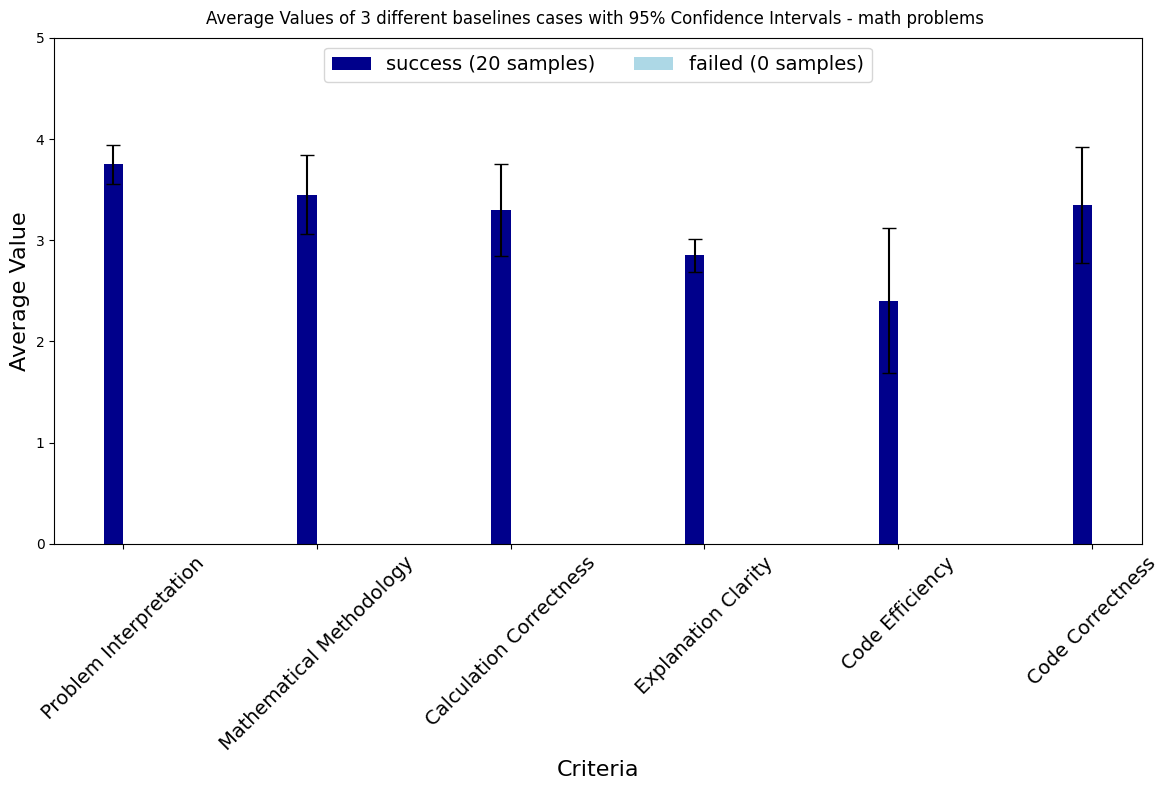

In [ ]:
plt.figure(figsize=(12, 8))
bar_width = 0.1
index = np.arange(len(criteria))


plt.bar(
    index,
    list(average_s.values()),
    bar_width,
    label=f"success ({len(task['s'])} samples)",
    color="darkblue",
    yerr=[(avg - conf_interval_s[key][0]) for key, avg in average_s.items()],
    capsize=5,
)
plt.bar(
    index + bar_width,
    list(average_f.values()),
    bar_width,
    label=f"failed ({len(task['f'])} samples)",
    color="lightblue",
    yerr=[(avg - conf_interval_f[key][0]) for key, avg in average_f.items()],
    capsize=5,
)

plt.xlabel("Criteria", fontsize=16)
plt.ylabel("Average Value", fontsize=16)
plt.title(
    "Average Values with 95% Confidence Intervals - math problems ", fontsize=12, pad=10
)
plt.xticks(
    index + bar_width / 2, [crit.name for crit in criteria], rotation=45, fontsize=14
)
plt.legend(
    loc="upper center", fontsize=14, bbox_to_anchor=(0.5, 1), ncol=3
)  # Adjust legend placement and ncol
plt.tight_layout()
plt.ylim(0, 5)
plt.savefig("/content/estimated_performance.png")
plt.show()

Kod ten oblicza średnie i przedziały ufności dla wyników oceny poszczególnych kryteriów.

Najpierw próbuje wczytać kryteria oceny z pliku `criteria_file` (tak jak poprzednio), używając bloku `with suppress(Exception):`.  Blok ten ma na celu obsłużenie potencjalnych błędów podczas odczytu lub parsowania pliku, ignorując je i kontynuując działanie programu.

Następnie tworzony jest słownik `nl2int`, który mapuje wartości tekstowe akceptowanych wyników (np. "correct", "incorrect") na odpowiadające im wartości liczbowe (indeksy). Iteruje po każdym kryterium w liście `criteria` i dla każdego z nich iteruje po jego akceptowanych wartościach (`criterion.accepted_values`).  Dla każdej wartości tekstowej przypisywana jest jej wartość indeksu w liście `accepted_values`. Na końcu kod wyświetla zawartość słownika `nl2int`.

Następnie inicjalizowane są cztery słowniki:
*   `average_s`: Przechowuje średnie wyniki dla udanych przypadków testowych (success).
*   `average_f`: Przechowuje średnie wyniki dla nieudanych przypadków testowych (failed).
*   `conf_interval_s`: Przechowuje przedziały ufności dla udanych przypadków testowych.
*   `conf_interval_f`: Przechowuje przedziały ufności dla nieudanych przypadków testowych.

Kod następnie iteruje po każdym kryterium w liście `criteria`. Dla każdego kryterium tworzony jest słownik `task`, który zawiera dwie listy: `s` (dla udanych przypadków) i `f` (dla nieudanych przypadków).

Wewnętrzna pętla iteruje po wszystkich wynikach oceny przechowywanych w słowniku `outcome`. Dla każdego wyniku próbuje wyodrębnić wyniki szacowanego działania (`estimated_performance`) za pomocą funkcji `eval()`.  Następnie, na podstawie wartości `"actual_success"` (czy przypadek testowy był udany czy nie), odpowiednia wartość z `tmp_dic` (wyniki szacowanego działania) jest pobierana dla danego kryterium (`criterion.name`), konwertowana na wartość liczbową za pomocą słownika `nl2int`, i dodawana do odpowiedniej listy w słowniku `task` (`s` lub `f`). Blok `with suppress(Exception):` obsługuje potencjalne błędy podczas wyodrębniania danych.

Po zebraniu wszystkich wyników dla danego kryterium, obliczana jest średnia wartość dla udanych i nieudanych przypadków testowych za pomocą funkcji `np.mean()`. Średnie wartości są przechowywane w słownikach `average_s` i `average_f`.

Następnie obliczane są 95% przedziały ufności dla udanych i nieudanych przypadków testowych za pomocą funkcji `stats.norm.interval()`. Funkcja ta wykorzystuje średnią (`loc`) i błąd standardowy średniej (`scale`, obliczony za pomocą `stats.sem()`). Przedziały ufności są przechowywane w słownikach `conf_interval_s` i `conf_interval_f`.